# Atelectasis vs Effusion (SVM & KNN - HOG Features)

This notebook classifies chest X-ray images from the **NIH Chest X-Ray dataset** into 2 disease classes:
- **Atelectasis**
- **Effusion**

Only single-label images are used (multi-label rows are excluded). HOG (Histogram of Oriented Gradients) features are extracted from the images and used to train two classifiers:

1. **SVM** (RBF kernel) - binary classification
2. **KNN** - trained with K=1 and K=27

Model performance is evaluated using classification report, confusion matrix, and ROC-AUC curves.

## Imports

In [1]:
import pandas as pd
import numpy as np
import os, glob, cv2, time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, f1_score, accuracy_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from skimage.feature import hog
from tqdm import tqdm
from skimage import exposure

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42

## Load CSV

In [2]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


## Select columns & map image paths

In [3]:
df = df[[
    'Image Index',
    'Finding Labels',
    'Follow-up #',
    'Patient ID',
    'Patient Age',
    'Patient Gender',
    'View Position'
]].copy()
df.columns = [
    'image_path',
    'labels',
    'followup_num',
    'patient_id',
    'age',
    'gender',
    'view_position'
]
BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
all_images = glob.glob(os.path.join(BASE_DIR, "images_*", "images", "*.png"))
path_dict = {os.path.basename(x): x for x in all_images}
df["image_path"] = df["image_path"].map(path_dict)
df.head(3)

,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Emphysema,1,1,58,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Effusion,2,1,58,M,PA


## Clean age outliers

In [4]:
print("Age stats before cleaning:")
print(df['age'].describe())

df = df[df['age'] <= 120].reset_index(drop=True)

print("Rows after age cleaning:", len(df))

Age stats before cleaning:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: age, dtype: float64
Rows after age cleaning: 112104


## Keep Single-Label Only

In [5]:
multi_mask = df["labels"].str.contains("\\|")
print(f"Multi-label rows : {multi_mask.sum():,}")
print(f"Single-label rows: {(~multi_mask).sum():,}")

df = df[~multi_mask].copy().reset_index(drop=True)
print(f"\nWorking dataframe shape: {df.shape}")
df.head()

Multi-label rows : 20,792
Single-label rows: 91,312

Working dataframe shape: (91312, 7)


,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,No Finding,0,2,81,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Hernia,0,3,81,F,PA
3,/kaggle/input/datasets/organizations/nih-chest...,Hernia,1,3,74,F,PA
4,/kaggle/input/datasets/organizations/nih-chest...,Hernia,2,3,75,F,PA


## Using 2 Disease Classes (Atelectasis, Effusion)

In [6]:
df_atelectasis = df[df["labels"] == "Atelectasis"]
df_effusion = df[df["labels"] == "Effusion"]

df_balanced = pd.concat([
    df_atelectasis,
    df_effusion
]).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["labels"].value_counts())
print(f"Final shape: {df_balanced.shape}")

labels
Atelectasis    4214
Effusion       3955
Name: count, dtype: int64
Final shape: (8169, 7)


## Extract HOG features

In [7]:
IMG_SIZE = 224

def extract_hog_features(image_path, size=(IMG_SIZE, IMG_SIZE)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    return features

print("Extracting HOG features...")
hog_features = []
valid_indices = []

for idx, row in tqdm(df_balanced.iterrows(), total=len(df_balanced)):
    try:
        feat = extract_hog_features(row["image_path"])
        hog_features.append(feat)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Error at index {idx}: {e}")

X = np.array(hog_features)
y = df_balanced.loc[valid_indices, "labels"].values
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting HOG features...


100%|██████████| 8169/8169 [06:41<00:00, 20.36it/s]


Feature matrix shape: (8169, 26244)
Labels shape: (8169,)


## Encode labels & train-test split

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Effusion=1, Atelectasis=0 (alphabetical)
print("Classes:", le.classes_)
print("Encoded distribution:", np.bincount(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Classes: ['Atelectasis' 'Effusion']
Encoded distribution: [4214 3955]
Train: (6535, 26244), Test: (1634, 26244)


## Scale features

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling complete!


## Train SVM (GridSearchCV for best hyperparameters)

In [10]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

start = time.time()
print("Running GridSearchCV...")

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_SEED),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print(f"\nDone in {(time.time()-start)/60:.1f} min")
print(f"Best params: {grid.best_params_}")
print(f"Best CV F1 (macro): {grid.best_score_:.4f}")

svm_model = grid.best_estimator_
print("Test score:", svm_model.score(X_test_scaled, y_test))

Running GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Done in 250.0 min
Best params: {'C': 10, 'gamma': 'auto'}
Best CV F1 (macro): 0.6824
Test score: 0.7111383108935129


In [11]:
print(f"Model: {svm_model}")

Model: SVC(C=10, class_weight='balanced', gamma='auto', random_state=42)


## Predictions & classification report

In [12]:
y_pred = svm_model.predict(X_test_scaled)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:

              precision    recall  f1-score   support

 Atelectasis       0.72      0.73      0.72       843
    Effusion       0.71      0.69      0.70       791

    accuracy                           0.71      1634
   macro avg       0.71      0.71      0.71      1634
weighted avg       0.71      0.71      0.71      1634



## Confusion Matrix - SVM

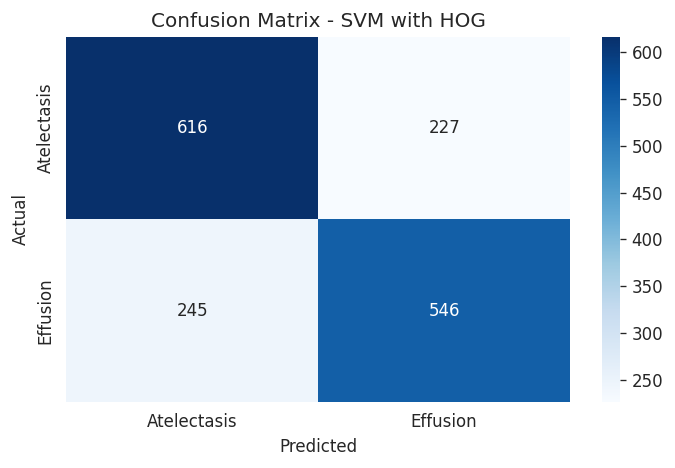

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM with HOG")
plt.tight_layout()
plt.show()

## ROC curves 

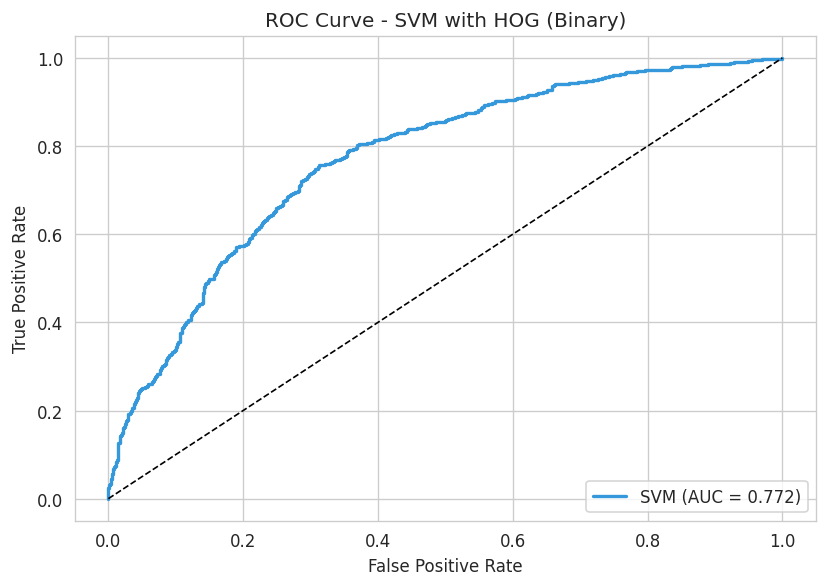

AUC: 0.7717


In [14]:
y_scores = svm_model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f"SVM (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM with HOG (Binary)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"AUC: {auc:.4f}")

## KNN Classification (K=1 and K=27)

In [15]:
# K=1
knn_1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_1.fit(X_train_scaled, y_train)

# K=27
knn_27 = KNeighborsClassifier(n_neighbors=27, n_jobs=-1)
knn_27.fit(X_train_scaled, y_train)

print("KNN training complete!")

KNN training complete!


## Predictions for both

In [16]:
y_pred_k1 = knn_1.predict(X_test_scaled)
y_pred_k27 = knn_27.predict(X_test_scaled)

print("=== KNN K=1 ===\n")
print(classification_report(y_test, y_pred_k1, target_names=le.classes_))

print("\n=== KNN K=27 ===\n")
print(classification_report(y_test, y_pred_k27, target_names=le.classes_))

=== KNN K=1 ===

              precision    recall  f1-score   support

 Atelectasis       0.61      0.68      0.64       843
    Effusion       0.61      0.53      0.57       791

    accuracy                           0.61      1634
   macro avg       0.61      0.60      0.60      1634
weighted avg       0.61      0.61      0.60      1634


=== KNN K=27 ===

              precision    recall  f1-score   support

 Atelectasis       0.61      0.83      0.71       843
    Effusion       0.71      0.44      0.54       791

    accuracy                           0.64      1634
   macro avg       0.66      0.64      0.62      1634
weighted avg       0.66      0.64      0.63      1634



## ROC curves for both KNN models

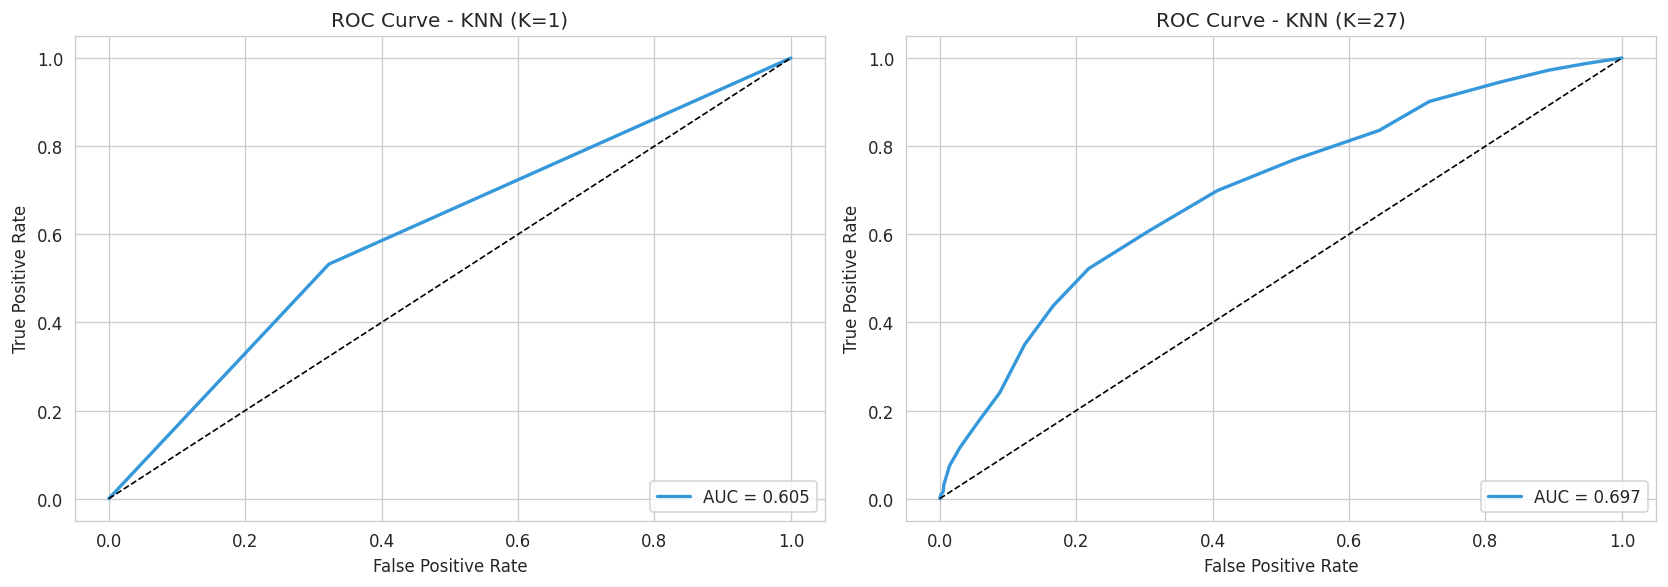

In [17]:
# KNN uses predict_proba for ROC since it doesn't have decision_function like SVM
y_prob_k1 = knn_1.predict_proba(X_test_scaled)[:, 1]
y_prob_k27 = knn_27.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_sc, k in zip(axes, [y_prob_k1, y_prob_k27], [1, 27]):
    fpr, tpr, _ = roc_curve(y_test, y_sc)
    auc = roc_auc_score(y_test, y_sc)
    ax.plot(fpr, tpr, color='#3498db', lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - KNN (K={k})")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Compare all 3 models (SVM, KNN-1, KNN-27)

In [18]:
y_scores_svm = svm_model.decision_function(X_test_scaled)

models = {
    "SVM (RBF)": (y_pred, y_scores_svm),
    "KNN (K=1)": (y_pred_k1, y_prob_k1),
    "KNN (K=27)": (y_pred_k27, y_prob_k27),
}

comparison = []
for name, (preds, scores) in models.items():
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    auc = roc_auc_score(y_test, scores)
    comparison.append({"Model": name, "Accuracy": acc, "F1 (macro)": f1, "AUC": auc})

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

     Model  Accuracy  F1 (macro)      AUC
 SVM (RBF)  0.711138    0.710607 0.771738
 KNN (K=1)  0.607099    0.603760 0.604790
KNN (K=27)  0.641983    0.624036 0.696645
